# Example application
The example (code and data) shown here are available in the 
`/docs/example` directory of the [HydroBM repository](https://github.com/wknoben/hydrobm).


## Example data
This example uses data obtained from the Caravan data set (Kratzert et al., 2023). To reduce repository size only the "total_precipitation_sum", "temperature_2m_mean", and "streamflow" variables are retained in `camels_01022500_minimal.nc`.

### Subsetting code
For full reproducibility, download the original Caravan data and use this code to subset.

```
import numpy as np
import xarray as xr

# Load the data
data_file = 'camels_01022500.nc'
mini_file = 'camels_01022500_minimal.nc'

data = xr.open_dataset(data_file)
keep = ['date', 'streamflow', 'total_precipitation_sum', 'temperature_2m_mean']
mini = data.drop_vars([var for var in data.variables if not var in keep])
mask = np.isnan(mini['streamflow'])
mini = mini.isel(date=~mask)
mini.to_netcdf(mini_file)

```

### References
Kratzert, F., Nearing, G., Addor, N., Erickson, T., Gauch, M., Gilon, O., Gudmundsson, L., Hassidim, A., Klotz, D., Nevo, S., Shalev, G., and Matias, Y.: Caravan - A global community dataset for large-sample hydrology, Scientific Data, 10, 61, https://doi.org/10.1038/s41597-023-01975-w, 2023.

## Example application

In [1]:
from hydrobm.calculate import calc_bm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
# Get the example data
data_file = './camels_01022500_minimal.nc'
data = xr.open_dataset(data_file)

### Create an exploratory plot
This shows that snow likely plays a role in this basin. 

Note that `matplotlib` is not a dependency of `hydrobm` and thus will not be automatically installed if it isn't already present on your system.

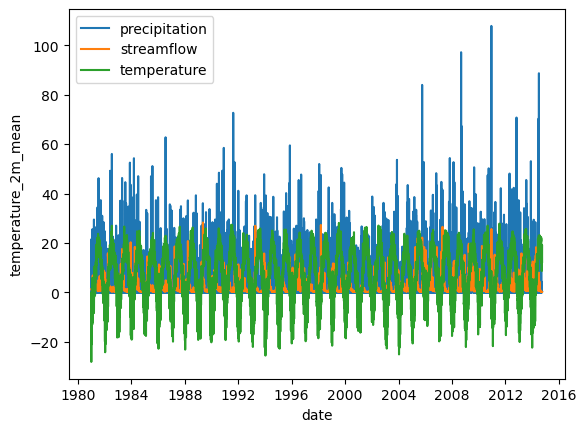

In [3]:
fig,ax = plt.subplots(1,1)
data['total_precipitation_sum'].plot(ax=ax, label='precipitation')
data['streamflow'].plot(ax=ax, label='streamflow')
data['temperature_2m_mean'].plot(ax=ax, label='temperature')
plt.legend();

### Run HydroBM
For this example, we'll calculate all benchmarks and all metrics, as well as estimate a snow melt flux from the precipitation and temperature data. 

First, we'll specify time masks for benchmark calculation and validation. These are arbitrary choices and will depend on your data availability and study purpose.

In [4]:
# Specify the calculation and evaluation periods, as boolean masks
cal_mask = data['date'].values < np.datetime64('1999-01-01')
val_mask = ~cal_mask

Next, we'll specify the benchmarks we want to calculate. 
We'll go for the full ensemble available in HydroBM at the time of its initial release.

This will trigger a warning when we run HydroBM, because the `annual_mean_flow` and `annual_median_flows` shouldn't be used in combination with a `val_mask`, but we'll accept that for this example. As a consequence, we'll also see some NumPy warnings when HydroBM runs it's benchmark validation for these two benchmarks.

In [5]:
# Specify the benchmarks and metrics to calculate
benchmarks = [
        # Streamflow benchmarks
        # =====================
        "mean_flow",
        "median_flow",
        "annual_mean_flow",
        "annual_median_flow",
        "monthly_mean_flow",
        "monthly_median_flow",
        "daily_mean_flow",
        "daily_median_flow",
    
        # Precipitation and streamflow benchmarks
        # =====================
        # Long-term rainfall-runoff ratio benchmarks
        "rainfall_runoff_ratio_to_all",
        "rainfall_runoff_ratio_to_annual",
        "rainfall_runoff_ratio_to_monthly",
        "rainfall_runoff_ratio_to_daily",
        "rainfall_runoff_ratio_to_timestep",
        "scaled_precipitation_benchmark",  # equivalent to "rainfall_runoff_ratio_to_daily"

         # Short-term rainfall-runoff ratio benchmarks
        "monthly_rainfall_runoff_ratio_to_monthly",
        "monthly_rainfall_runoff_ratio_to_daily",
        "monthly_rainfall_runoff_ratio_to_timestep",

        # Precipitation deviation benchmarks
        "annual_scaled_daily_mean_flow",
        "monthly_scaled_daily_mean_flow",
    
        # Parsimonious models
        # =====================
        "eckhardt_baseflow",
    
        # Schaefli & Gupta (2007) benchmarks
        "adjusted_precipitation_benchmark",
        "adjusted_smoothed_precipitation_benchmark", # from Schaefli & Gupta (2007)
     ]

We'll also calculate values for the four statistics available in HydroBM at its initial release. 

Note that automatically calculating certain metric scores is included in HydroBM as a quality-of-life feature, but HydroBM's usage is not limited to these metrics only. HydroBMs main purpose is to create the benchmark simulation time series and return these to the user. If your metric of choice is not (yet) available within HydroBM, simply use HydroBM to generate the benchmark model timeseries and calculate the metric yourself from those.

Of course, you could always consider contributing your metric code to the HydroBM package through its [GitHub reposity](https://github.com/wknoben/hydrobm) :)

In [6]:
metrics = ['nse', 'kge', 'mse', 'rmse']

Now we're ready to run the whole thing. Because we only have precipitation data, but know that snow is important, we'll also run HydroBM's simple snow model (`calc_snowmelt = True`). When running everything through `calc_bm`, enabling the snow routine will automatically internally use the resulting snow-plus-melt flux to calculate any requested benchmarks.

Note that if you have an external snow model you like better, you can simply run that and feed that timeseries into HydroBM by changing the `precipitation` variable name to that of your own rain-plus-melt timeseries in `data`.

We'll stick with the default values for `snowmelt_threshold` (threshold between rain and snow), `snowmelt_rate` (how quickly does accumulated snow melt) and `optimization_method` (how do we find optimal lag/smoothing values for the APB and ASPB benchmarks), but I've included them here anyway to show how/that they can be adjusted. See the `Usage` part of the documentation for further details.

This is the part where all the work is done (run snow model, create benchmark timeseries, calculate metric values) and running this will take a minute or two. Note that we'll get some warnings from both HydroBM and NumPy because we're combining `val_mask` with two benchmarks that by definition are incompatible with the concept of unseen data.

In [7]:
# Calculate the benchmarks and scores
benchmark_flows,scores = calc_bm(
                            data,
                
                            # Time period selection
                            cal_mask,
                            val_mask=val_mask,
                
                            # Variable names in 'data'
                            precipitation="total_precipitation_sum",
                            streamflow="streamflow",
                
                            # Benchmark choices
                            benchmarks=benchmarks,
                            metrics=metrics,
                            optimization_method="brute_force",
                
                            # Snow model inputs
                            calc_snowmelt=True,
                            temperature="temperature_2m_mean",
                            snowmelt_threshold=0.0,
                            snowmelt_rate=3.0,
                        )

/work/comphyd_lab/local/modules/spack/2024v5/core/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder/linux-rocky8-x86_64/gcc-14.2.0/py-numpy-1.26.4-4gvcfkg7xzi7ktldzplfxodbfcjqoyf3/lib/python3.11/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/work/comphyd_lab/local/modules/spack/2024v5/core/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder/linux-rocky8-x86_64/gcc-14.2.0/py-numpy-1.26.4-4gvcfkg7xzi7ktldzplfxodbfcjqoyf3/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)


### Visualize the benchmarks
First, lets visualze the timeseries of each benchmark. 

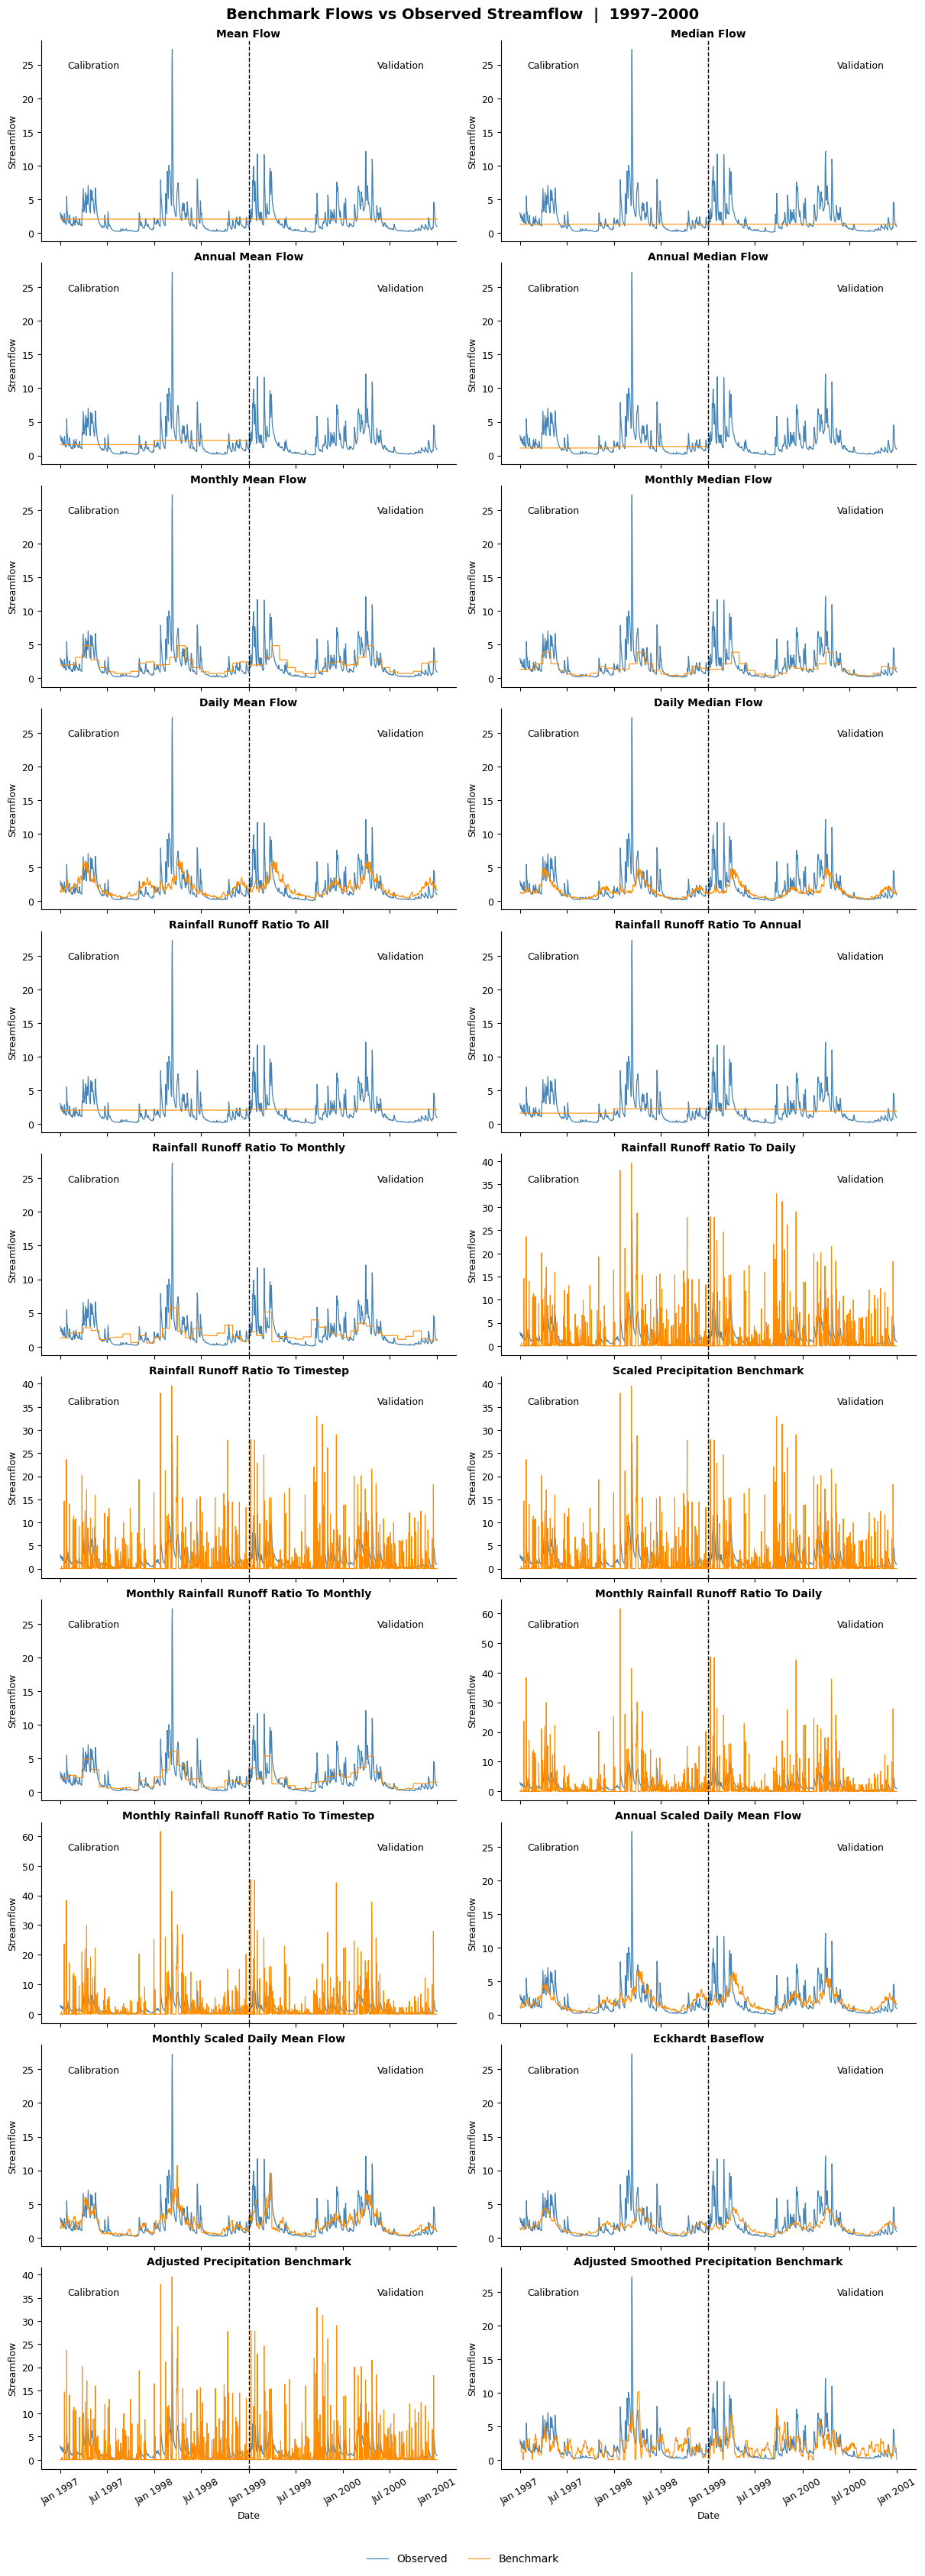

In [8]:
# Subset the benchmark flows between 1997 (calibration period) and 2000 (validation period)
bm_sub = benchmark_flows.loc["1997":"2000"]
# Subset the observed flow for the same period
qobs_sub = data.sel(date=slice("1997", "2000"))["streamflow"].to_series()
# Extract list of benchmarks
bm_cols = bm_sub.columns.tolist()

# Format plots
n_cols = 2
n_rows = -(-len(bm_cols) // n_cols)
# Find the last visible plot index in each column (for x-axis labels)
bottom_axes = set()
for c in range(n_cols):
    col_indices = [c + r * n_cols for r in range(n_rows) if c + r * n_cols < len(bm_cols)]
    if col_indices:
        bottom_axes.add(col_indices[-1])
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3), constrained_layout=True)
axes = axes.flatten()

split_date = pd.Timestamp("1999-01-01")

for i, name in enumerate(bm_cols):
    ax = axes[i]
    l1, = ax.plot(qobs_sub.index, qobs_sub.values, color="steelblue", linewidth=0.9, label="Observed")
    l2, = ax.plot(bm_sub.index, bm_sub[name].values, color="darkorange", linewidth=0.8, label="Benchmark")
    title = name.replace("bm_", "").replace("_", " ").title()
    ax.set_title(title, fontsize=10, fontweight="bold", pad=3)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="y", labelsize=9)
    ax.set_ylabel("Streamflow", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    # Vertical line at calibration/validation split
    ax.axvline(split_date, color="black", linewidth=1.0, linestyle="--", zorder=3)

    # Cal / Val labels
    trans = ax.get_xaxis_transform()
    ax.text(split_date - pd.Timedelta(days=500), 0.9,
            "Calibration", transform=trans, ha="right", va="top", fontsize=9, color="black")
    ax.text(split_date + pd.Timedelta(days=500), 0.9,
            "Validation", transform=trans, ha="left", va="top", fontsize=9, color="black")

    if i in bottom_axes:
        ax.tick_params(axis="x", labelsize=9, rotation=30)
        ax.set_xlabel("Date", fontsize=9)
    else:
        ax.tick_params(axis="x", labelbottom=False)

for j in range(len(bm_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Benchmark Flows vs Observed Streamflow  |  1997–2000", fontsize=14, fontweight="bold")
fig.legend(handles=[l1, l2], labels=["Observed", "Benchmark"],
           loc="lower center", ncol=2, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.show()

Each benchmark produces a different timeseries. The Annual Mean and Median Flow benchmarks only produce values for the calibration period (1998), as they cannot be used on unseen data. 

### Analyze the results
Here's some basic analysis of the resulting benchmarks and their scores. Feel free to build your own analysis from this!

In [9]:
# Print the scores with some basic formatting applied
for key,val in scores.items():
    if key == 'benchmarks':
        print(f'{key}: {val}')
    else:
        pm = [f'{num:.2f}' for num in val]
        print(f'{key}: {pm}')

benchmarks: ['mean_flow', 'median_flow', 'annual_mean_flow', 'annual_median_flow', 'monthly_mean_flow', 'monthly_median_flow', 'daily_mean_flow', 'daily_median_flow', 'rainfall_runoff_ratio_to_all', 'rainfall_runoff_ratio_to_annual', 'rainfall_runoff_ratio_to_monthly', 'rainfall_runoff_ratio_to_daily', 'rainfall_runoff_ratio_to_timestep', 'scaled_precipitation_benchmark', 'monthly_rainfall_runoff_ratio_to_monthly', 'monthly_rainfall_runoff_ratio_to_daily', 'monthly_rainfall_runoff_ratio_to_timestep', 'annual_scaled_daily_mean_flow', 'monthly_scaled_daily_mean_flow', 'eckhardt_baseflow', 'adjusted_precipitation_benchmark', 'adjusted_smoothed_precipitation_benchmark']
nse_cal: ['0.00', '-0.11', '0.03', '-0.09', '0.24', '0.17', '0.29', '0.20', '0.00', '0.02', '0.17', '-3.33', '-3.33', '-3.33', '0.37', '-3.93', '-3.93', '0.31', '0.43', '0.24', '-2.38', '0.35']
nse_val: ['-0.01', '-0.14', 'nan', 'nan', '0.19', '0.09', '0.19', '0.10', '-0.00', '0.04', '0.19', '-2.96', '-2.96', '-2.96', '0.26

Not very clear. Let's create some hydrographs as well.

In [10]:
# Select the four best benchmarks for plotting
def top_n_indices_and_values(values_list, n=4):
    arr = np.array(values_list) # numpy array
    nan_idx = np.where(np.isnan(arr)) # find nan values
    arr_sort = arr.argsort() # sort the full array, nans go at the end
    arr_sort = arr_sort[~np.isin(arr_sort, nan_idx)] # remove nans
    indices = arr_sort[-n:] # get the top n indices
    values = arr[indices] # get the values
    return indices.tolist(), values.tolist()

In [11]:
idx,vals = top_n_indices_and_values(scores['kge_val'], 4)
top_benchmarks = [scores['benchmarks'][id] for id in idx]
top_kge_vals = [scores['kge_val'][id] for id in idx]

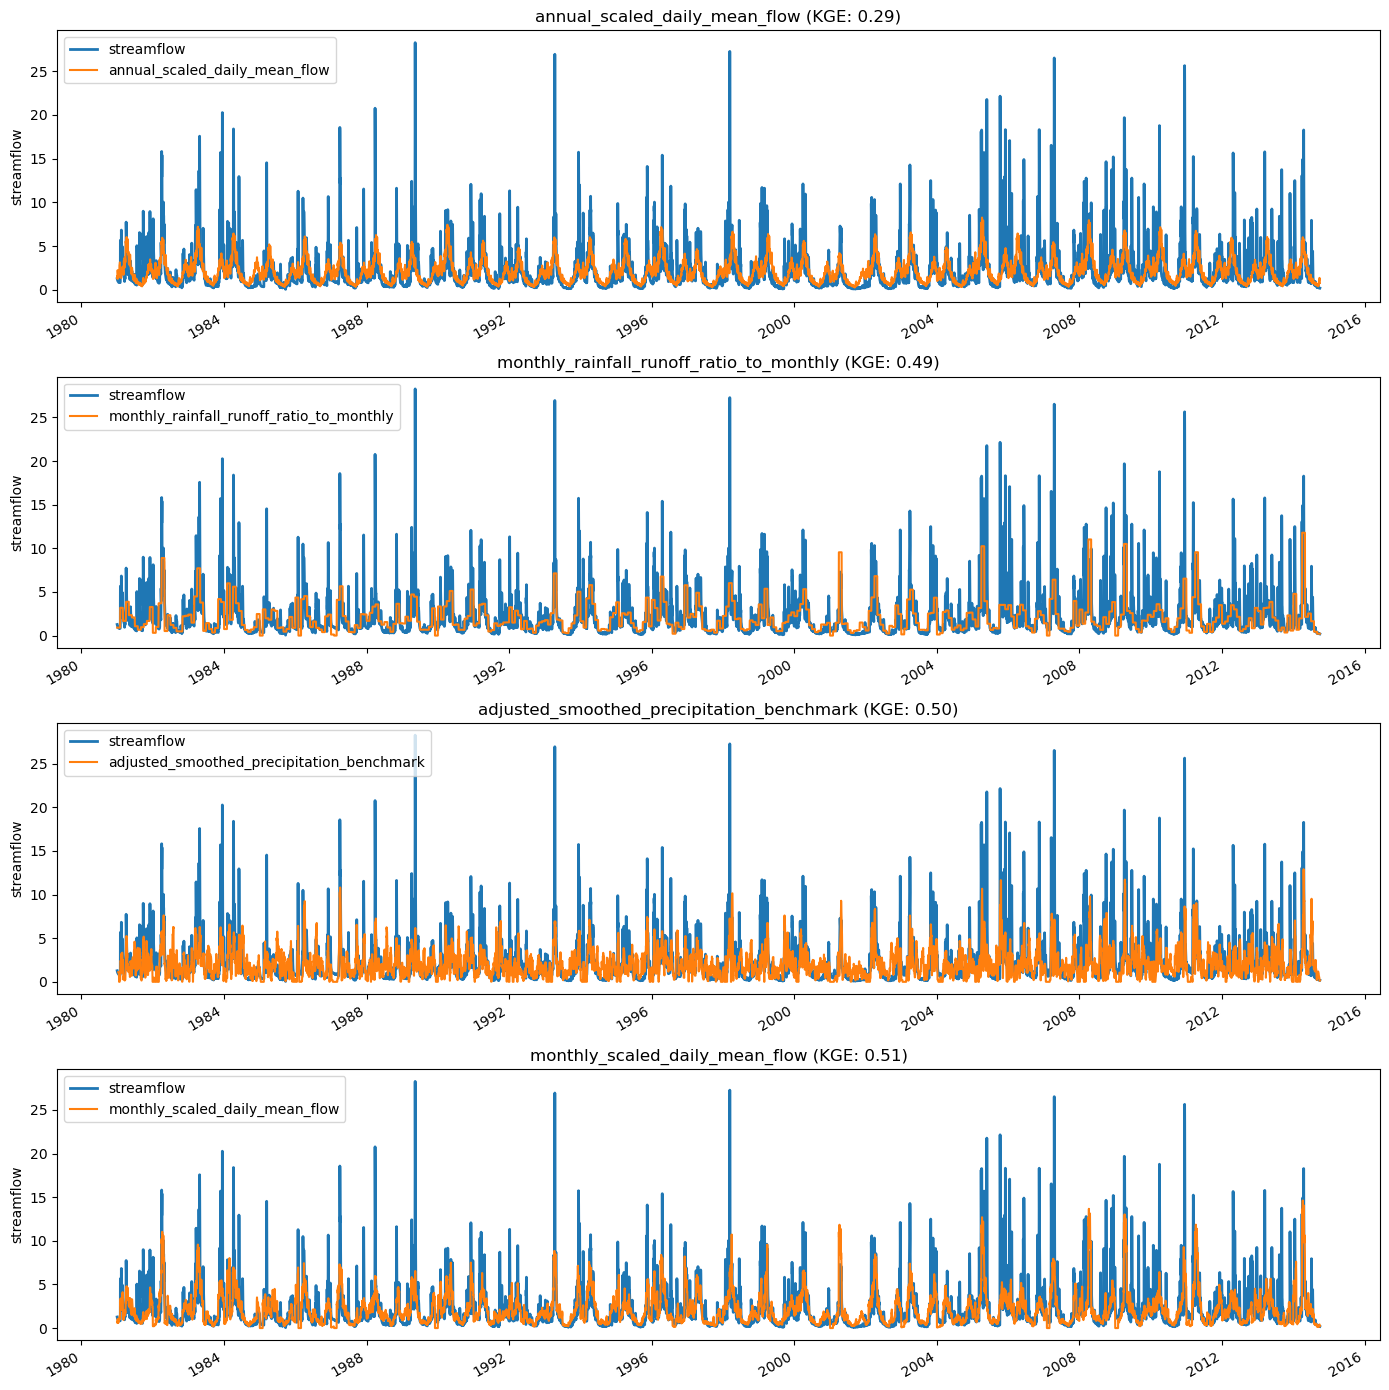

In [12]:
# Print streamflow along with the four best benchmarks
fig,ax = plt.subplots(4,1, figsize=(14,14))
for i,(bm,kge) in enumerate(zip(top_benchmarks,top_kge_vals)):
    data['streamflow'].plot(ax=ax[i], linewidth=2, label='streamflow')
    benchmark_flows[f'bm_{bm}'].plot(ax=ax[i], label=bm)
    ax[i].legend(loc='upper left')
    ax[i].set_title(f'{bm} (KGE: {kge:.2f})')
    ax[i].set_xlabel('') # drops 'Date'
    
plt.tight_layout()

In [13]:
# Reformat the scores a bit for cleaner saving 
col_names = scores.pop("benchmarks", None)
df = pd.DataFrame(scores, index=col_names)
df = df.T

In [14]:
# Uncomment these to save the benchmark models and scores
#  No point doing that here while building the documentation.
#df.to_csv("benchmark_scores.csv")
#benchmark_flows.to_csv("benchmark_flows.csv")